In [1]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt


In [2]:
RAW_DATA_PATH = "data/raw"
OUTPUT_PATH = "data/mel_spectrograms"

CLASSES = [
    "belly_pain",
    "burping",
    "discomfort",
    "hungry",
    "tired"
]

os.makedirs(OUTPUT_PATH, exist_ok=True)


In [ ]:
def save_mel_spectrogram(
    audio_path,
    save_path,
    sr=22050,
    n_mels=128,
    n_fft=2048,
    hop_length=512
):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(4, 4))
    librosa.display.specshow(
        mel_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="mel"
    )
    plt.axis("off")   # IMPORTANT for CNN
    plt.tight_layout(pad=0)

    plt.savefig(save_path, dpi=150, bbox_inches="tight", pad_inches=0)
    plt.close()


In [4]:
for class_name in CLASSES:
    class_input_path = os.path.join(RAW_DATA_PATH, class_name)
    class_output_path = os.path.join(OUTPUT_PATH, class_name)

    os.makedirs(class_output_path, exist_ok=True)

    for file in os.listdir(class_input_path):
        if file.endswith(".wav"):
            audio_path = os.path.join(class_input_path, file)
            save_path = os.path.join(
                class_output_path,
                file.replace(".wav", ".png")
            )

            save_mel_spectrogram(audio_path, save_path)

    print(f"Done for class: {class_name}")


Done for class: belly_pain
Done for class: burping
Done for class: discomfort
Done for class: hungry
Done for class: tired


In [21]:
import os
import librosa
import numpy as np
def mel_feature_vector(
    filepath,
    sr=22050,
    n_mels=128,
    n_fft=2048,
    hop_length=512
):
    y, sr = librosa.load(filepath, sr=sr, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Mean + std over time axis
    mel_mean = np.mean(mel_db, axis=1)
    mel_std  = np.std(mel_db, axis=1)

    return np.hstack([mel_mean, mel_std])  # (256,)


In [ ]:
DATASET_PATH = "data/raw"

CLASSES = [
    "belly_pain",
    "burping",
    "discomfort",
    "hungry",
    "tired"
]

X = []
y = []

for label, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_dir):
        if file.endswith(".wav"):
            filepath = os.path.join(class_dir, file)

            features = mel_feature_vector(filepath)

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (samples, 256)
print("y shape:", y.shape)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'updated-melspec\\belly_pain'

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=10,        # small dataset → small perplexity
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE output shape:", X_tsne.shape)


t-SNE output shape: (457, 2)


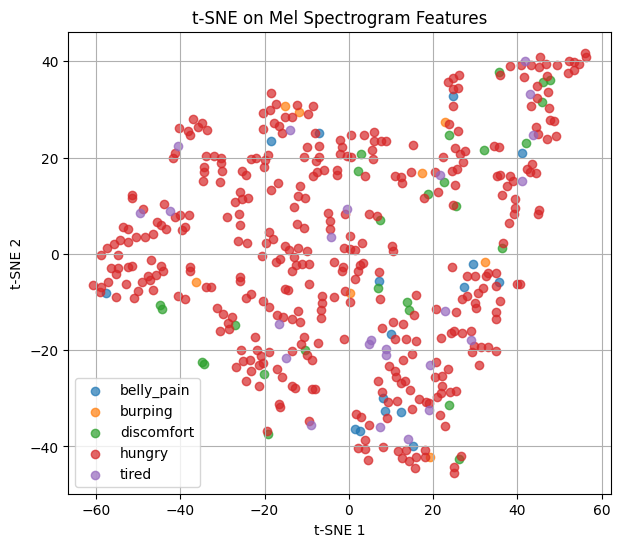

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for label, class_name in enumerate(CLASSES):
    idx = y == label
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        
        label=class_name,
        alpha=0.7
    )

plt.legend()
plt.title("t-SNE on Mel Spectrogram Features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()
